In [4]:
# Pytorch Workflow:
# Let explore the example Pytorch end to end workflow


In [5]:
import torch
from torch  import nn  # contains pytorch building blokcs for nns
import matplotlib.pyplot as plt

torch.__version__

'2.8.0+cu126'

In [6]:
# data preparing and loading
# Data can be anything in ML :
# Images, Videos spreadsheets, audio, table of numbers ..etc

# Machine learning:
# 1: get data into a numerical representation,
# 2: Build the model to learn patterns in that numerical representaion.




In [7]:
# create a *Known* parameter

weight = 0.7
bias = 0.3

# create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10], len(X), len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

In [8]:
len(X), len(y)


(50, 50)

In [9]:
# Splitting data into training and testing
# Creating proper train and test set is the most important part in ML
# Creating training and test set
tarin_split = int(0.8 * len(X))
X_train, y_train = X[:tarin_split], y[:tarin_split]
X_test, y_test = X[tarin_split:], y[tarin_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [10]:
X_train, y_train

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260],
         [0.4400],
         [0.4540],
         [

In [11]:
import matplotlib.pyplot as plt

def plot_prediction(train_data=X_train,
                    train_label=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                    predictions=None):
    """
    Plots training and test data, and compares predictions if provided.
    """
    plt.figure(figsize=(10, 7))

  # Plot training data
    plt.scatter(train_data, train_label, c="b", s=4, label="Training data")

  # Plot test data
    plt.scatter(test_data, test_labels, c="g", s=4, label="Test data")

  # Plot predictions if available
    if predictions is not None:
      plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    plt.legend(prop={"size": 14});
    # plt.show()


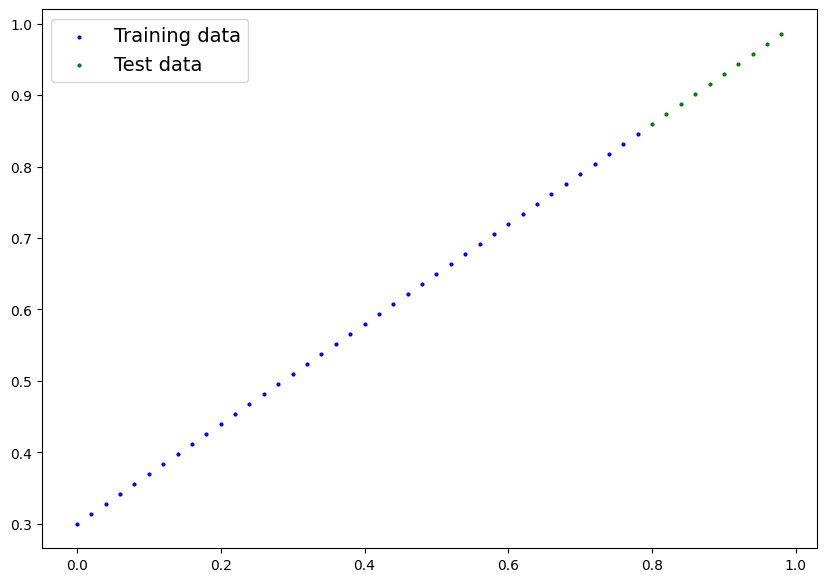

In [13]:
plot_prediction()

Visualize, Visualize and Visualize .... Whenever working with data and turtning it to numbers it is better to visualize it

In [14]:
import torch
from torch import nn

# Building First PyTorch model
# Creating a linear regression model class.

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        # start with random weight; this will be adjusted as the model learns
        self.weights = nn.Parameter(torch.randn(1, dtype=torch.float32, requires_grad=True))
        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float32, requires_grad=True))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Linear regression formula: y = w * x + b
        return self.weights * x + self.bias


# Important note: here the nn.Modules has all the  building blocks for nn


In [16]:
### Chenking the content of the pytorch model
# creating a random_seed


torch.manual_seed(42)

model_0 = LinearRegressionModel()


list(model_0.parameters())


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [17]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making Predication using `torch.inference_mode()`

In [18]:
# Make predictions with model

with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds



tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [19]:
# Checking the predictions
print(f"Number of testing samples:  {len(X_test)}")
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values: \n{y_preds}")

Number of testing samples:  10
Number of predictions made: 10
Predicted values: 
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


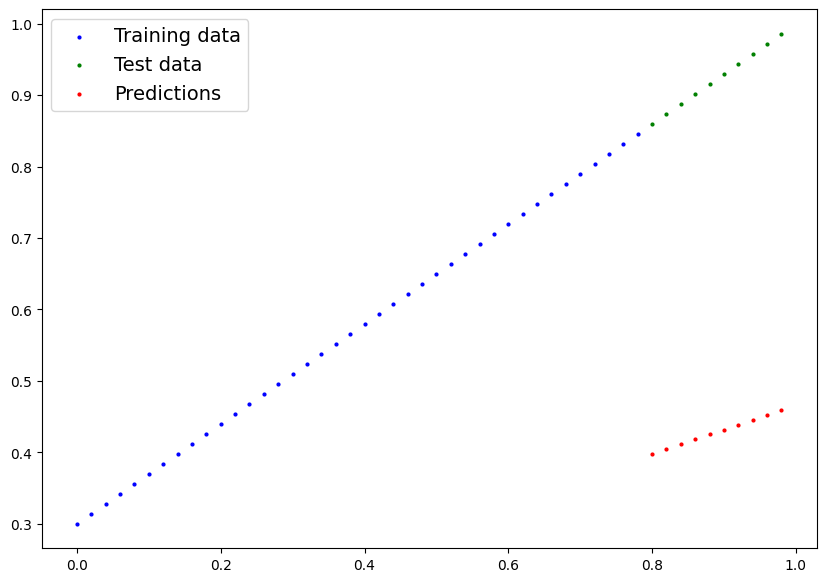

In [22]:
plot_prediction(predictions=y_preds)

In [24]:
y_test = y_preds

# Creating a loss function, which depnds on the type of problem we work

However there are some common values that are known to work well such as *SGD* or *Adam optimizer*. And *MAE* loss function for regression problems or binary cross entropy loss function for classification problems (predicting one thing or another)  

# Here we use MAE:  
Which measures the absolute difference between 2 points (predictions and labels )
and then takes the mean across all examples .

params : is the target model parameters you like to optimize ( eg: weights, and bias values we randomly set before )
lr : Learning rate : Higher means the optimizer try larger updates (these can sometimes be too large and optimizer doesn't work well ) lower means the optimizer try smaller updates ( these can sometimes be too small and optimizer will take too long to find the ideal values)

*Common values are* 0.01, 0.001, 0.0001




In [26]:
# Create a loss function:
loss_fn = nn.L1Loss()   # MAE loss is the same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),  # parameters of target model to optimize
                            lr=0.01) # # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))


follow this link for fun:  https://en.wikipedia.org/wiki/Neural_network_(machine_learning)

Whole idea of training is for a model to move from *Unknown* parameters to some *Known* parameters

Or from a poor representation to  a better representation of the data

Using Loss fn: is a good measure  ( aka cost fun:)



##Train Model

In [47]:
import torch

torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 4000

# Create empty loss lists to track the values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    # Training

    # Put the model in training mode (default, but still good practice)
    model_0.train()

    # 1. Forward pass on the training data
    y_pred = model_0(X_train)

    # 2. Calculate the loss (how different are our predictions from the truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero the gradients
    optimizer.zero_grad()

    # 4. Backward pass (compute gradients)
    loss.backward()  #
    # 5. Step the optimizer (update weights)
    optimizer.step()

    # Testing
    model_0.eval()
    with torch.inference_mode():  # disables gradient calculation
        # 1. Forward pass on test data
        test_pred = model_0(X_test)

        # 2. Calculate loss on test data
        test_loss = loss_fn(test_pred, y_test).type(torch.float)

    # Record and print every 10 epochs
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        train_loss_values.append(loss.detach().numpy())
        test_loss_values.append(test_loss.detach().numpy())
        print(f"Epoch: {epoch} | MAE Train Loss: {loss.item():.4f} | MAE Test Loss: {test_loss.item():.4f}")


Epoch: 0 | MAE Train Loss: 0.0089 | MAE Test Loss: 0.4895
Epoch: 10 | MAE Train Loss: 0.0089 | MAE Test Loss: 0.4895
Epoch: 20 | MAE Train Loss: 0.0089 | MAE Test Loss: 0.4895
Epoch: 30 | MAE Train Loss: 0.0089 | MAE Test Loss: 0.4895
Epoch: 40 | MAE Train Loss: 0.0089 | MAE Test Loss: 0.4895
Epoch: 50 | MAE Train Loss: 0.0089 | MAE Test Loss: 0.4895
Epoch: 60 | MAE Train Loss: 0.0089 | MAE Test Loss: 0.4895
Epoch: 70 | MAE Train Loss: 0.0089 | MAE Test Loss: 0.4895
Epoch: 80 | MAE Train Loss: 0.0089 | MAE Test Loss: 0.4895
Epoch: 90 | MAE Train Loss: 0.0089 | MAE Test Loss: 0.4895
Epoch: 100 | MAE Train Loss: 0.0089 | MAE Test Loss: 0.4895
Epoch: 110 | MAE Train Loss: 0.0089 | MAE Test Loss: 0.4895
Epoch: 120 | MAE Train Loss: 0.0089 | MAE Test Loss: 0.4895
Epoch: 130 | MAE Train Loss: 0.0089 | MAE Test Loss: 0.4895
Epoch: 140 | MAE Train Loss: 0.0089 | MAE Test Loss: 0.4895
Epoch: 150 | MAE Train Loss: 0.0089 | MAE Test Loss: 0.4895
Epoch: 160 | MAE Train Loss: 0.0089 | MAE Test Loss

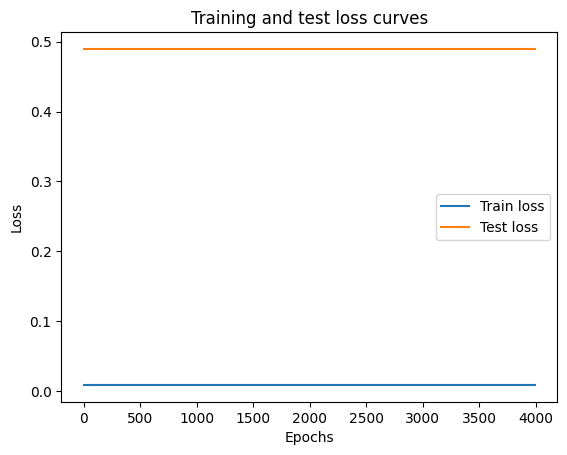

In [48]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

## Making Predictions with a trained PyTorch model (inference)

There are three things to remember when making predictions (also called performing inference) with a PyTorch model:

1)     Set the model in evaluation mode (model.eval()).

2)     Make the predictions using the inference mode context manager (with torch.inference_mode(): ...).
 3)    All predictions should be made with objects on the same device (e.g. data and model on GPU only or data and model on CPU only).


In [50]:
# Set the model in evaluation mode
model_0.eval()

# 2. SetUp the inference mode context manager
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

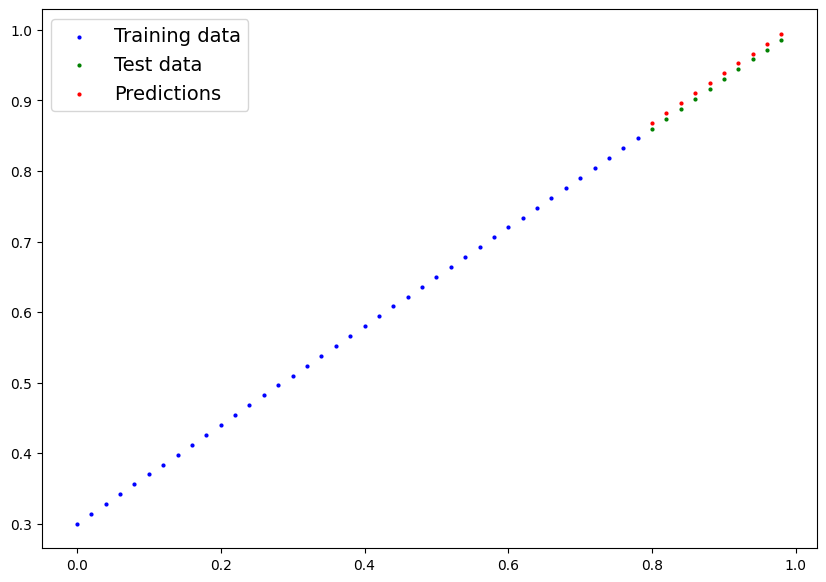

In [51]:
plot_prediction(predictions=y_preds)

## Saving Pytorch model's state_dict()


In [53]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_0.pth


In [54]:
# Check the saved file path
!ls -l models/01_pytorch_workflow_model_0.pth


-rw-r--r-- 1 root root 2117 Oct 26 04:18 models/01_pytorch_workflow_model_0.pth


## Loading the saved pytorch model's state_dict()

In [55]:
# Instantiate a new instance of our model (this will be instantiated with random weights)
loaded_model_0 = LinearRegressionModel()

# Load the state dict of our saved model (this will update the new instance of our model with trained weights)

loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [56]:
# Put the loaded model to the evaluation mode
loaded_model_0.eval()

# 2. Use the inference mode context manager to make predictions
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)   # Perform a forward pass on the test data with the loaded model


In [58]:
# Compare previous model predictions with loaded model prediction (these should be same )
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

It looks like that model predictions are the same as the previous model predications (predictions made prior to saving) . This indicates our model is saving and loading as expected

## Summary ##
